# CNN-LSTM — Human Activity Recognition
**CS3244 Group 32 | Nabil Rakaiza Abror**

Dataset: Smartphone-Based Recognition of Human Activities and Postural Transitions (UCI)

This file contains the source code for evaluating a **CNN-LSTM** framework using a dataset of **561 engineered features**. It documents several experiments conducted to optimize performance under different configurations:
* **Baseline Model:** A standard CNN-LSTM architecture without additional modifications.
* **Class Weighting:** Adjusting loss function weights as an alternative strategy for imbalanced data.
* **SMOTE Integration:** Implementing Synthetic Minority Over-sampling Technique to address class imbalance.

### Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, LSTM, Dense, Dropout,
    BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers.legacy import Adam

from imblearn.over_sampling import SMOTE

import os
import warnings
warnings.filterwarnings("ignore")

### Reading Data and Helper Functions

In [2]:
X_train = pd.read_csv('data/Train/X_train.txt', sep=r'\s+', header=None).values
y_train = pd.read_csv('data/Train/Y_train.txt', sep=r'\s+', header=None).values.ravel()
X_test  = pd.read_csv('data/Test/X_test.txt',  sep=r'\s+', header=None).values
y_test  = pd.read_csv('data/Test/Y_test.txt',  sep=r'\s+', header=None).values.ravel()

labels_df        = pd.read_csv('data/activity_labels.txt', sep=r'\s+', header=None)
activity_mapping = dict(zip(labels_df[0], labels_df[1]))
label_names      = [activity_mapping[i] for i in sorted(activity_mapping)]

print(f'X_train: {X_train.shape} | y_train: {y_train.shape}')
print(f'X_test:  {X_test.shape}  | y_test:  {y_test.shape}')
print(f'Classes: {label_names}')

X_train: (7767, 561) | y_train: (7767,)
X_test:  (3162, 561)  | y_test:  (3162,)
Classes: ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING', 'STAND_TO_SIT', 'SIT_TO_STAND', 'SIT_TO_LIE', 'LIE_TO_SIT', 'STAND_TO_LIE', 'LIE_TO_STAND']


Helper Functions

In [3]:
def build_cnn_lstm_model(n_timesteps, n_features, n_classes, dropout_rate=0.5, lr=0.001):
    model = Sequential([
        Conv1D(64, 3, activation="relu", padding="same",
               input_shape=(n_timesteps, n_features)),
        BatchNormalization(),
        Conv1D(64, 3, activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling1D(2),
        Dropout(dropout_rate),

        Conv1D(128, 3, activation="relu", padding="same"),
        BatchNormalization(),
        Conv1D(128, 3, activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling1D(2),
        Dropout(dropout_rate),

        LSTM(128, return_sequences=True),
        Dropout(dropout_rate),
        LSTM(64, return_sequences=False),
        Dropout(dropout_rate),

        Dense(64, activation="relu"),
        Dropout(dropout_rate),
        Dense(n_classes, activation="softmax"),
    ], name="CNN_LSTM")

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


def plot_training_history(history):
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="train")
    plt.plot(history.history["val_accuracy"], label="val")
    plt.title("Training Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="train")
    plt.plot(history.history["val_loss"], label="val")
    plt.title("Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(cm, labels, title="Confusion Matrix"):
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


def mean_iou_from_cm(cm):
    ious = []
    for i in range(len(cm)):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        denom = tp + fp + fn
        ious.append(tp / denom if denom > 0 else 0.0)
    return np.mean(ious)


def plot_roc_auc(y_true_onehot, y_score, label_names):
    n_classes = len(label_names)
    plt.figure(figsize=(10, 8))
    auc_scores = []

    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true_onehot[:, i], y_score[:, i])
        score = auc(fpr, tpr)
        auc_scores.append(score)
        plt.plot(fpr, tpr, label=f"{label_names[i]} (AUC={score:.3f})")

    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.title(f"ROC-AUC Curve (One-vs-Rest) - Macro ROC-AUC :{np.mean(auc_scores):.4f}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right", fontsize="small")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_iou_bars(cm, label_names):
    ious = []
    for i in range(len(cm)):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        denom = tp + fp + fn
        ious.append(tp / denom if denom > 0 else 0.0)

    macro_iou = np.mean(ious)

    plt.figure(figsize=(10, 5))
    sns.barplot(x=label_names, y=ious, palette="Blues_d")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("IoU")
    plt.xlabel("Activity")
    plt.title("Per-Class IoU with Macro-Mean")
    plt.ylim(0, 1)
    plt.axhline(macro_iou, color="red", linestyle="--", linewidth=2,
                label=f"Macro IoU = {macro_iou:.4f}")
    plt.legend()
    plt.tight_layout()
    plt.show()


def evaluate_model(model, X, y_true, y_true_cat, label_names):
    y_pred_probs = model.predict(X)
    y_pred_classes = np.argmax(y_pred_probs, axis=1)

    cm = confusion_matrix(y_true, y_pred_classes)
    plot_confusion_matrix(cm, label_names)
    print("==" * 60)
    print("==" * 60)
    print("Classification Report:")
    print(classification_report(y_true, y_pred_classes, target_names=label_names))
    print("==" * 60)
    print("==" * 60)
    print("Mean IoU Score")
    print(f"Mean IoU: {mean_iou_from_cm(cm):.4f}")
    plot_iou_bars(cm, label_names)
    print("==" * 60)
    print("==" * 60)
    plot_roc_auc(y_true_cat, y_pred_probs, label_names)

### Normal Configuration

Starting training...
Epoch 1/100
98/98 [==============================] - 32s 307ms/step - loss: 1.6409 - accuracy: 0.3184 - val_loss: 2.5724 - val_accuracy: 0.1390
Epoch 2/100
98/98 [==============================] - 44s 453ms/step - loss: 1.2239 - accuracy: 0.4687 - val_loss: 2.8313 - val_accuracy: 0.2355
Epoch 3/100
98/98 [==============================] - 43s 437ms/step - loss: 0.8541 - accuracy: 0.6557 - val_loss: 3.3818 - val_accuracy: 0.1390
Epoch 4/100
98/98 [==============================] - 43s 435ms/step - loss: 0.7194 - accuracy: 0.6894 - val_loss: 1.1214 - val_accuracy: 0.6030
Epoch 5/100
98/98 [==============================] - 43s 444ms/step - loss: 0.6293 - accuracy: 0.7349 - val_loss: 2.3171 - val_accuracy: 0.3925
Epoch 6/100
98/98 [==============================] - 44s 449ms/step - loss: 0.6046 - accuracy: 0.7563 - val_loss: 0.4213 - val_accuracy: 0.8732
Epoch 7/100
98/98 [==============================] - 45s 456ms/step - loss: 0.5663 - accuracy: 0.7774 - val_loss: 0

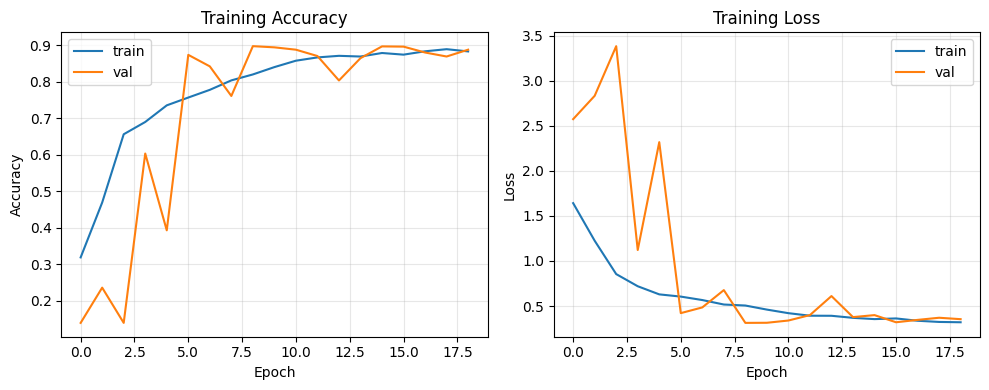

99/99 [==============================] - 11s 107ms/step


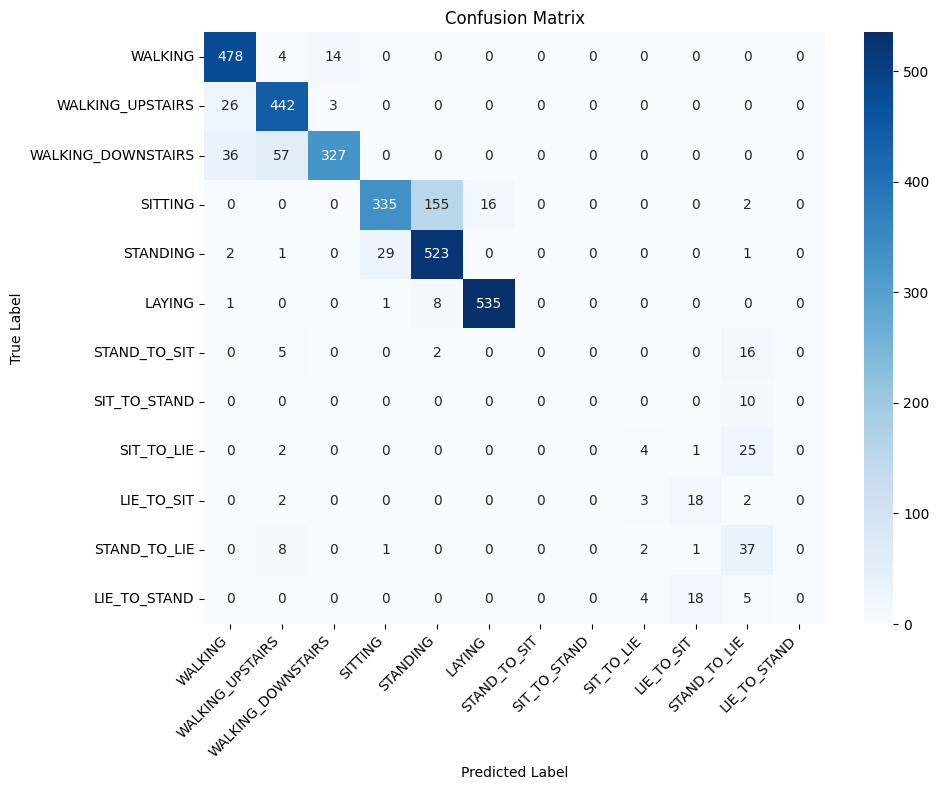

Classification Report:
                    precision    recall  f1-score   support

           WALKING       0.88      0.96      0.92       496
  WALKING_UPSTAIRS       0.85      0.94      0.89       471
WALKING_DOWNSTAIRS       0.95      0.78      0.86       420
           SITTING       0.92      0.66      0.77       508
          STANDING       0.76      0.94      0.84       556
            LAYING       0.97      0.98      0.98       545
      STAND_TO_SIT       0.00      0.00      0.00        23
      SIT_TO_STAND       0.00      0.00      0.00        10
        SIT_TO_LIE       0.31      0.12      0.18        32
        LIE_TO_SIT       0.47      0.72      0.57        25
      STAND_TO_LIE       0.38      0.76      0.50        49
      LIE_TO_STAND       0.00      0.00      0.00        27

          accuracy                           0.85      3162
         macro avg       0.54      0.57      0.54      3162
      weighted avg       0.85      0.85      0.84      3162

Mean IoU Score

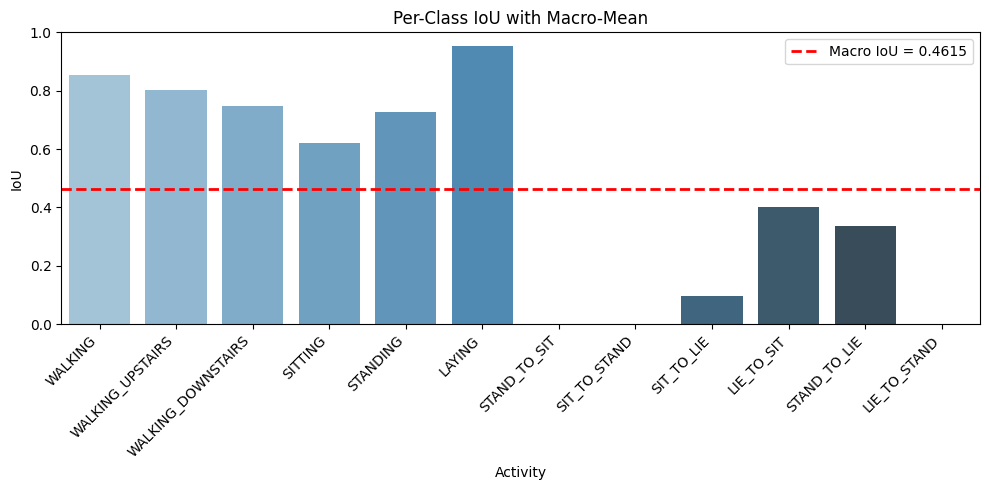

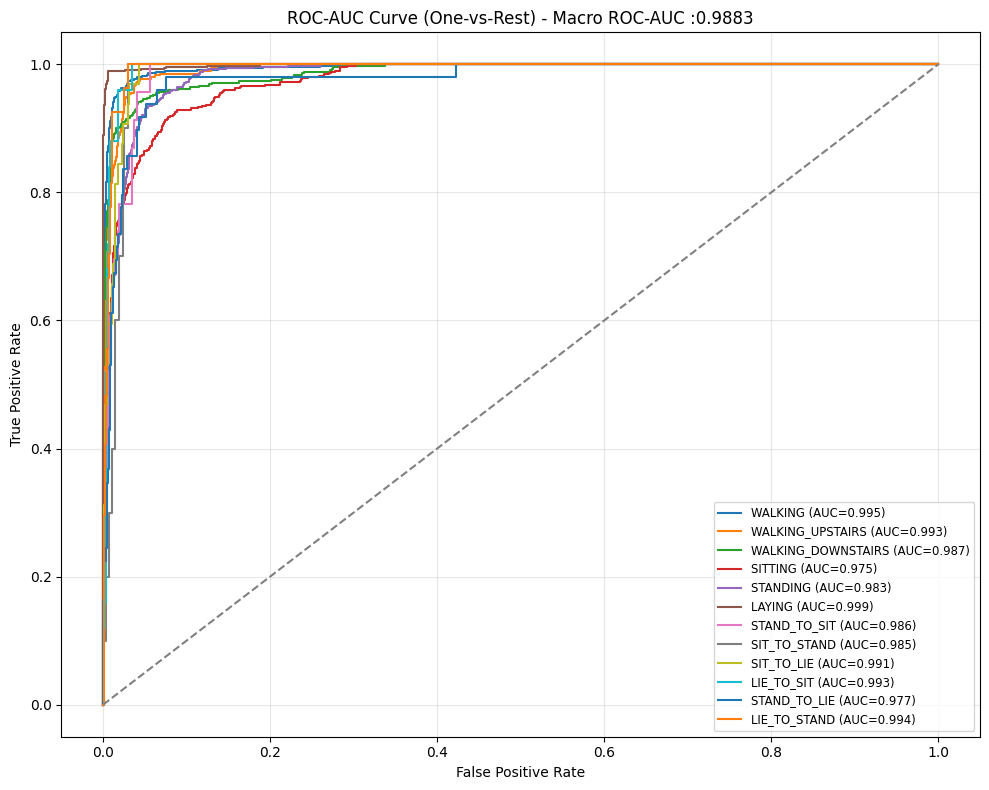

In [4]:
n_timesteps = 561
n_features = 1
dropout_rate = 0.5
n_classes = len(label_names)
lr = 0.001

model = build_cnn_lstm_model(n_timesteps, n_features, n_classes, dropout_rate, lr)

y_train_0 = y_train - 1
y_test_0 = y_test - 1

X_train_k = X_train.reshape(-1, n_timesteps, n_features)
X_test_k = X_test.reshape(-1, n_timesteps, n_features)

y_train_cat = to_categorical(y_train_0, num_classes=n_classes)
y_test_cat = to_categorical(y_test_0, num_classes=n_classes)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

print("Starting training...")
history = model.fit(
    X_train_k,
    y_train_cat,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

test_loss, test_acc = model.evaluate(X_test_k, y_test_cat)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

plot_training_history(history)
evaluate_model(model, X_test_k, y_test_0, y_test_cat, label_names)

### Class Weight Approach

Starting training...
Epoch 1/100
98/98 [==============================] - 88s 872ms/step - loss: 2.3800 - accuracy: 0.2115 - val_loss: 2.7938 - val_accuracy: 0.0116
Epoch 2/100
98/98 [==============================] - 80s 818ms/step - loss: 2.0034 - accuracy: 0.3094 - val_loss: 3.0473 - val_accuracy: 0.1474
Epoch 3/100
98/98 [==============================] - 84s 860ms/step - loss: 1.8792 - accuracy: 0.3710 - val_loss: 3.0630 - val_accuracy: 0.1390
Epoch 4/100
98/98 [==============================] - 77s 790ms/step - loss: 1.7619 - accuracy: 0.3963 - val_loss: 3.3390 - val_accuracy: 0.1390
Epoch 5/100
98/98 [==============================] - 75s 770ms/step - loss: 1.6931 - accuracy: 0.4217 - val_loss: 2.9991 - val_accuracy: 0.0663
Epoch 6/100
98/98 [==============================] - 72s 738ms/step - loss: 1.6488 - accuracy: 0.4370 - val_loss: 1.2048 - val_accuracy: 0.4086
Epoch 7/100
98/98 [==============================] - 69s 702ms/step - loss: 1.5980 - accuracy: 0.4481 - val_loss: 1

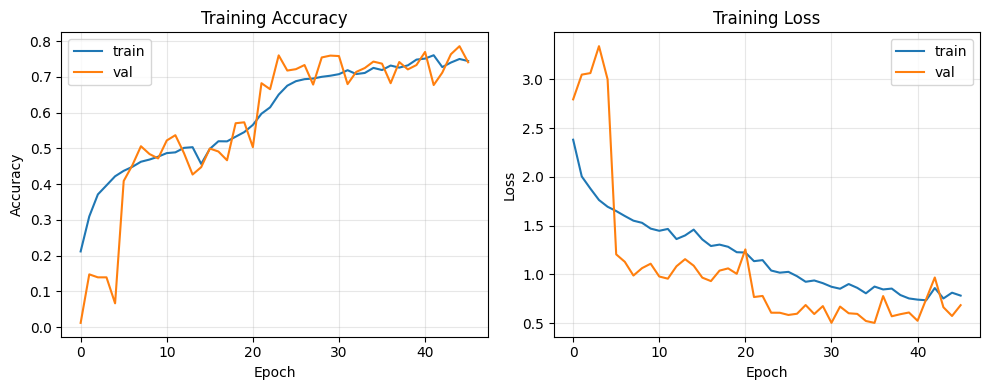

99/99 [==============================] - 9s 87ms/step


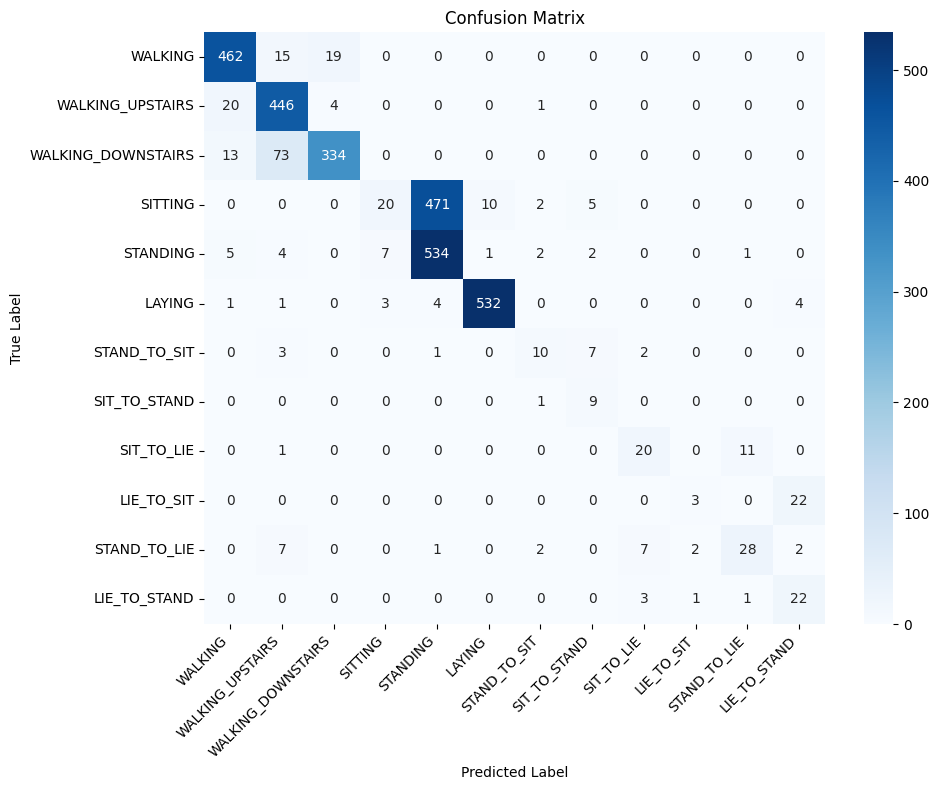

Classification Report:
                    precision    recall  f1-score   support

           WALKING       0.92      0.93      0.93       496
  WALKING_UPSTAIRS       0.81      0.95      0.87       471
WALKING_DOWNSTAIRS       0.94      0.80      0.86       420
           SITTING       0.67      0.04      0.07       508
          STANDING       0.53      0.96      0.68       556
            LAYING       0.98      0.98      0.98       545
      STAND_TO_SIT       0.56      0.43      0.49        23
      SIT_TO_STAND       0.39      0.90      0.55        10
        SIT_TO_LIE       0.62      0.62      0.62        32
        LIE_TO_SIT       0.50      0.12      0.19        25
      STAND_TO_LIE       0.68      0.57      0.62        49
      LIE_TO_STAND       0.44      0.81      0.57        27

          accuracy                           0.77      3162
         macro avg       0.67      0.68      0.62      3162
      weighted avg       0.79      0.77      0.72      3162

Mean IoU Score

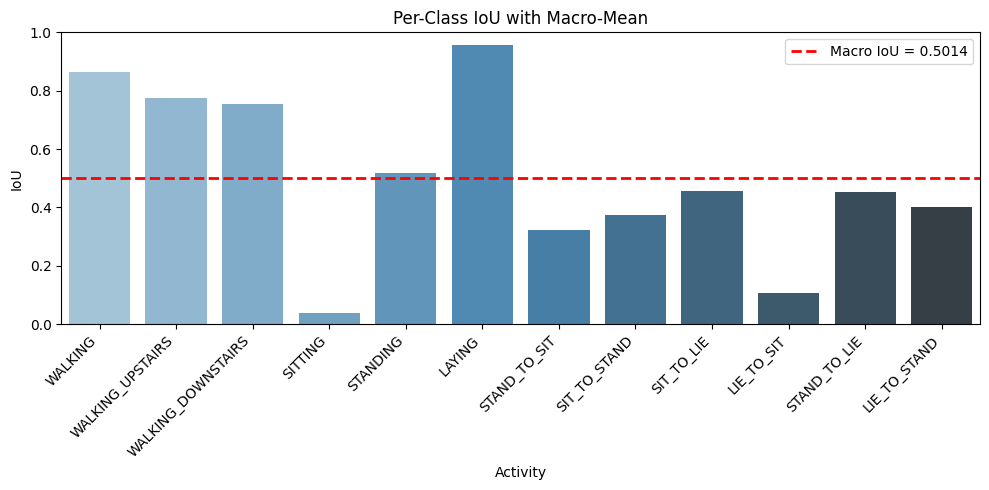

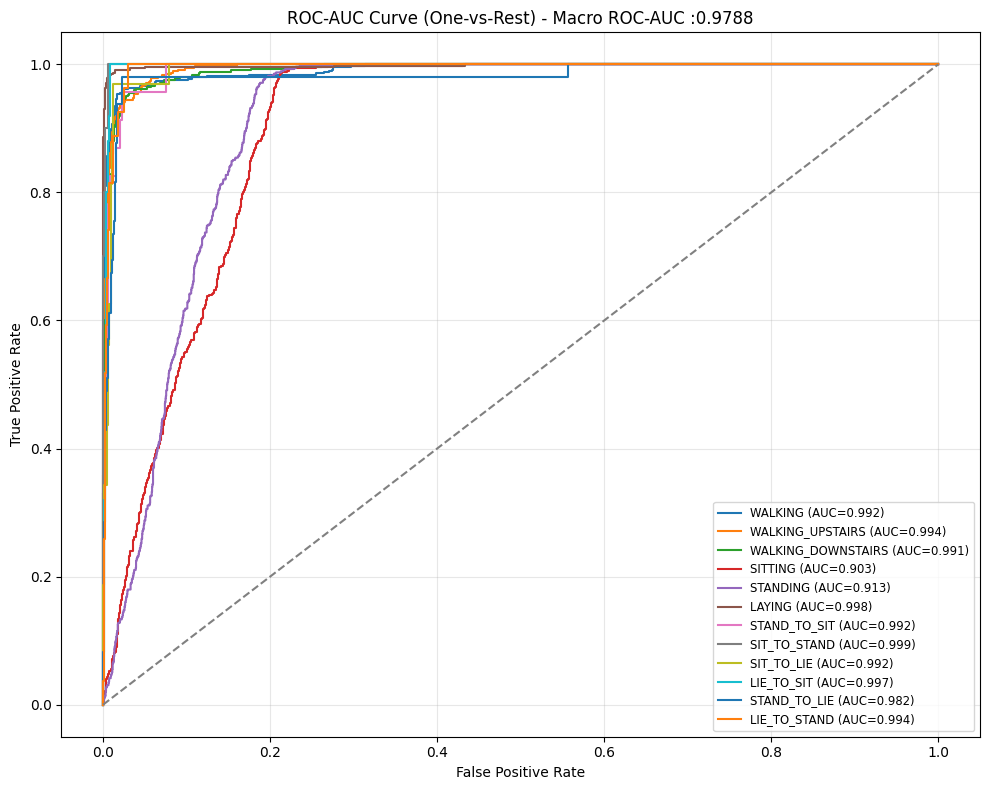

In [5]:
n_timesteps = 561
n_features = 1
dropout_rate = 0.5
n_classes = len(label_names)
lr = 0.001

model = build_cnn_lstm_model(n_timesteps, n_features, n_classes, dropout_rate, lr)

y_train_0 = y_train - 1
y_test_0 = y_test - 1

X_train_k = X_train.reshape(-1, n_timesteps, n_features)
X_test_k = X_test.reshape(-1, n_timesteps, n_features)

y_train_cat = to_categorical(y_train_0, num_classes=n_classes)
y_test_cat = to_categorical(y_test_0, num_classes=n_classes)

computed_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_0),
    y=y_train_0
)
class_weights_dict = dict(enumerate(computed_weights))

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

print("Starting training...")
history = model.fit(
    X_train_k,
    y_train_cat,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    class_weight=class_weights_dict
)

test_loss, test_acc = model.evaluate(X_test_k, y_test_cat)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

plot_training_history(history)
evaluate_model(model, X_test_k, y_test_0, y_test_cat, label_names)

### SMOTE Approach

Starting training with SMOTE...
Epoch 1/100
214/214 [==============================] - 107s 487ms/step - loss: 1.8416 - accuracy: 0.2773 - val_loss: 4.1984 - val_accuracy: 0.0058
Epoch 2/100
214/214 [==============================] - 124s 578ms/step - loss: 1.0640 - accuracy: 0.5564 - val_loss: 0.9286 - val_accuracy: 0.5663
Epoch 3/100
214/214 [==============================] - 108s 507ms/step - loss: 0.7944 - accuracy: 0.6552 - val_loss: 0.5574 - val_accuracy: 0.7773
Epoch 4/100
214/214 [==============================] - 106s 495ms/step - loss: 0.6718 - accuracy: 0.7084 - val_loss: 0.4615 - val_accuracy: 0.8552
Epoch 5/100
214/214 [==============================] - 110s 513ms/step - loss: 0.6129 - accuracy: 0.7430 - val_loss: 0.3713 - val_accuracy: 0.8655
Epoch 6/100
214/214 [==============================] - 111s 518ms/step - loss: 0.5530 - accuracy: 0.7814 - val_loss: 0.3594 - val_accuracy: 0.8803
Epoch 7/100
214/214 [==============================] - 108s 505ms/step - loss: 0.4959 

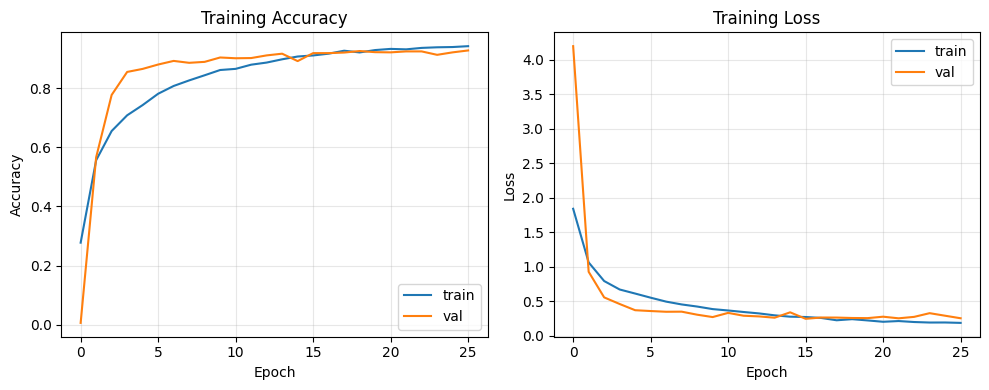

99/99 [==============================] - 14s 98ms/step


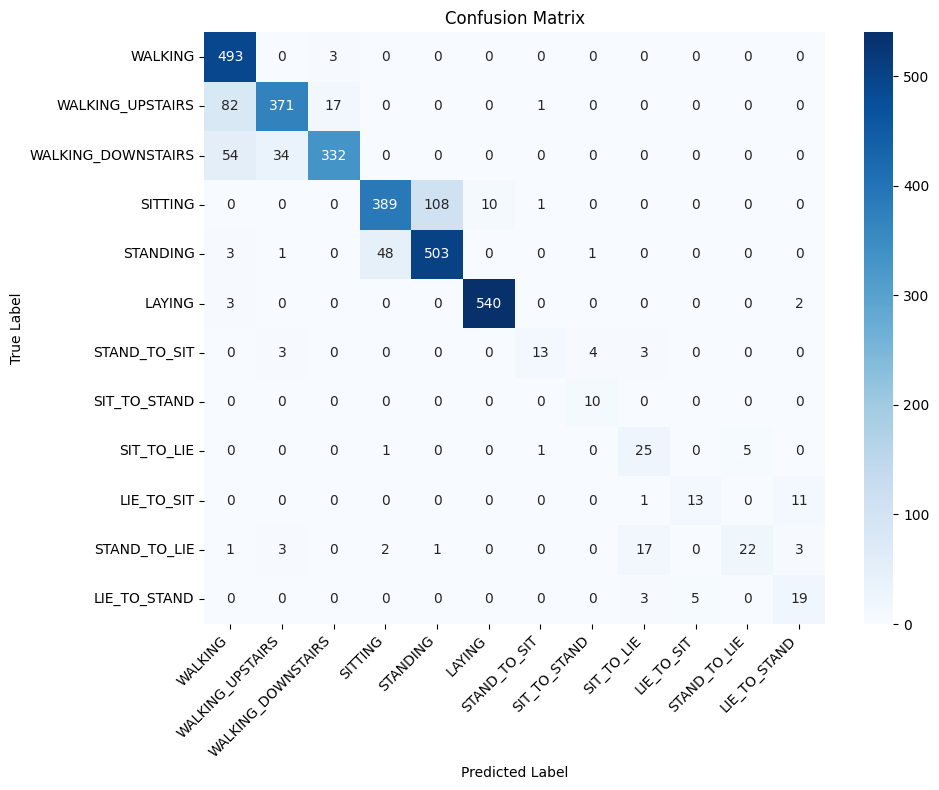

Classification Report:
                    precision    recall  f1-score   support

           WALKING       0.78      0.99      0.87       496
  WALKING_UPSTAIRS       0.90      0.79      0.84       471
WALKING_DOWNSTAIRS       0.94      0.79      0.86       420
           SITTING       0.88      0.77      0.82       508
          STANDING       0.82      0.90      0.86       556
            LAYING       0.98      0.99      0.99       545
      STAND_TO_SIT       0.81      0.57      0.67        23
      SIT_TO_STAND       0.67      1.00      0.80        10
        SIT_TO_LIE       0.51      0.78      0.62        32
        LIE_TO_SIT       0.72      0.52      0.60        25
      STAND_TO_LIE       0.81      0.45      0.58        49
      LIE_TO_STAND       0.54      0.70      0.61        27

          accuracy                           0.86      3162
         macro avg       0.78      0.77      0.76      3162
      weighted avg       0.87      0.86      0.86      3162

Mean IoU Score

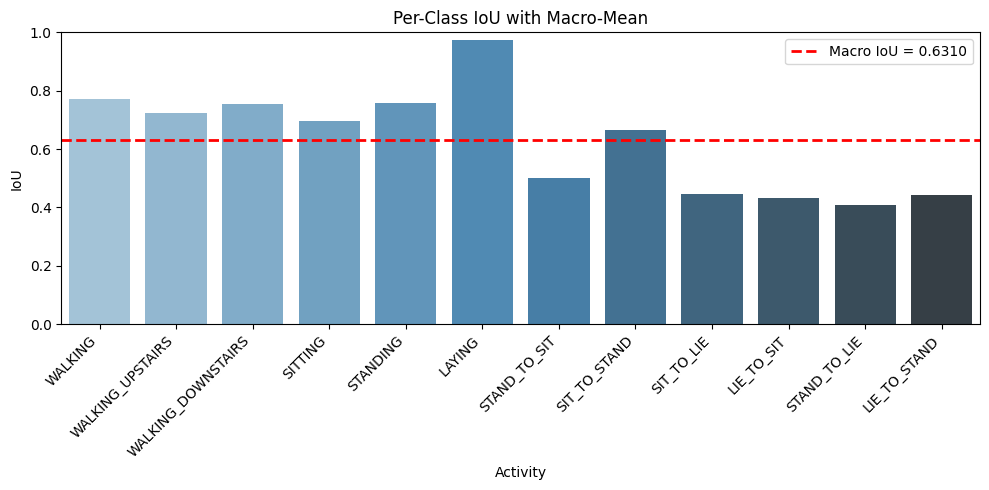

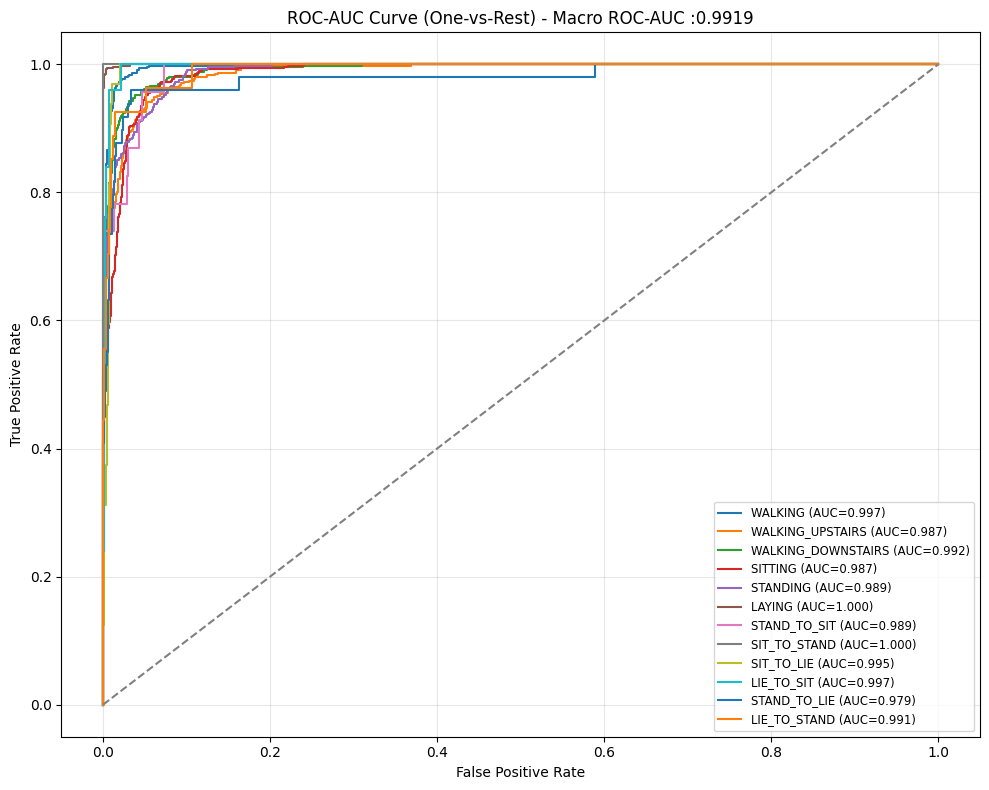

In [6]:
n_timesteps = 561
n_features = 1
dropout_rate = 0.5
n_classes = len(label_names)
lr = 0.001

model = build_cnn_lstm_model(n_timesteps, n_features, n_classes, dropout_rate, lr)

y_train_0 = y_train - 1
y_test_0 = y_test - 1

X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train,
    y_train_0,
    test_size=0.2,
    random_state=42,
    stratify=y_train_0
)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_sub, y_train_sub)

X_train_k = X_train_resampled.reshape(-1, n_timesteps, n_features)
X_val_k = X_val.reshape(-1, n_timesteps, n_features)
X_test_k = X_test.reshape(-1, n_timesteps, n_features)

y_train_cat = to_categorical(y_train_resampled, num_classes=n_classes)
y_val_cat = to_categorical(y_val, num_classes=n_classes)
y_test_cat = to_categorical(y_test_0, num_classes=n_classes)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

print("Starting training with SMOTE...")
history = model.fit(
    X_train_k,
    y_train_cat,
    validation_data=(X_val_k, y_val_cat),
    epochs=100,
    batch_size=64,
    callbacks=[early_stop]
)

test_loss, test_acc = model.evaluate(X_test_k, y_test_cat)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

plot_training_history(history)
evaluate_model(model, X_test_k, y_test_0, y_test_cat, label_names)